# Lozano-Smith Algorithm - Full problem

In [2]:
import pyomo.environ as pyo
from pyomo.opt import SolverFactory
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

EXEC_PATH = '/Applications/CPLEX_Studio221/cplex/bin/x86-64_osx/cplex'

In [3]:
data = pd.read_excel('../Instances/input.xlsx', None)

## Initialization

In [4]:
def INIT(data):
    
    model = pyo.ConcreteModel()  # create model

    mult = 1  # <--------------- multiplication factor for making the variable integer

    # data
    t = len(data['dataset']['Time'])
    PI = data['dataset']['Spot Market'].values.flatten() * mult
    l = len(data['Power price']['Power'])

    X_low = data['average']['MIN'].values.flatten() * mult
    X_up = data['average']['MAX'].values.flatten() * mult
    X_avg = 10

    p = len(data['periods']['PERIOD'])
    Q_begin = data['periods']['BEGIN'].tolist()
    Q_end = data['periods']['END'].tolist()
    Q_len = data['periods']['LEN'].tolist()

    i = len(data['Trip time']['Time begin (min)'])
    k = len(data['Buses']['Bus (kWh)'])
    n = len(data['Chargers']['Charger (kWh/min)'])
    T_start = data['Trip time']['Time begin (min)'].tolist()
    T_start = [int(x) for x in T_start]
    T_end = data['Trip time']['Time finish (min)'].tolist()
    T_end = [int(x) for x in T_end]
    alpha = data['Chargers']['Charger (kWh/min)'].tolist()
    beta = data['Chargers']['Charger (kWh/min)'].tolist()
    gama = data['Energy consumption']['Uncertain energy (kWh/km*min)'].tolist()
    ch_eff = 0.90
    dch_eff = 1/0.9
    E_0 = 0.2
    E_min = 0.2
    E_max = 1
    E_end = 0.2
    C_bat = data['Buses']['Bus (kWh)'].tolist()
    T = t

    U_pow = data['Power price']['Power'].tolist()
    U_price = data['Power price']['Price'].tolist()
    U_max = data['Chargers']['Max Power (kW)'].tolist()
    U_max = U_max[0]

    d_on = 1
    d_off = 1

    R = 130
    Ah = 905452
    V = 512
    T = 96

    # sets
    model.P = pyo.RangeSet(p)  # set of periods
    model.I = pyo.RangeSet(i)  # set of trips
    model.T = pyo.RangeSet(t)  # set of timesteps
    model.K = pyo.RangeSet(k)  # set of buses
    model.N = pyo.RangeSet(n)  # set of chargers
    model.L = pyo.RangeSet(l)  # set of chargers

    # parameters
    model.PI = pyo.Param(model.T, initialize=lambda model,
                        t: PI[t-1])  # spot market electricity prices
    # Period Q_p starting time
    model.Q_begin = pyo.Param(
        model.P, initialize=lambda model, p: Q_begin[p-1])
    # Period Q_p ending time
    model.Q_end = pyo.Param(model.P, initialize=lambda model, p: Q_end[p-1])
    model.Q_len = pyo.Param(model.P, initialize=lambda model,
                            p: Q_len[p-1])  # Period Q_p length
    # Mininum value price x can achieve
    model.X_low = pyo.Param(model.P, initialize=lambda model, p: X_low[p-1])
    # Maxinum value price x can achieve
    model.X_up = pyo.Param(model.P, initialize=lambda model, p: X_up[p-1])
    model.X_avg = pyo.Param(initialize=(X_avg))  # Average price x can achieve

    model.T_start = pyo.Param(
        model.I, initialize=lambda model, i: T_start[i-1])  # start time of trip i
    model.T_end = pyo.Param(model.I, initialize=lambda model,
                            i: T_end[i-1])  # end time of trip i
    # charging power of charger n
    model.alpha = pyo.Param(model.N, initialize=lambda model, n: alpha[n-1])
    model.beta = pyo.Param(model.N, initialize=lambda model,
                        n: beta[n-1])  # discharging power of charger n
    # charging efficiency of charger n
    model.ch_eff = pyo.Param(initialize=ch_eff)
    model.dch_eff = pyo.Param(initialize=dch_eff)
    model.gama = pyo.Param(model.I, initialize=lambda model,
                        i: gama[i-1], mutable=True)  # energy consumption
    model.E_0 = pyo.Param(initialize=E_0)  # initial energy level of bus k
    # minimum energy level allowed for bus k
    model.E_min = pyo.Param(initialize=E_min)
    # maximum energy level allowed for bus k
    model.E_max = pyo.Param(initialize=E_max)
    # minimum energy after an operation day for bus k
    model.E_end = pyo.Param(initialize=E_end)
    # total capacity of the bus k battery
    model.C_bat = pyo.Param(model.K, initialize=lambda model, k: C_bat[k-1])

    model.U_pow = pyo.Param(model.L, initialize=lambda model,
                            l: U_pow[l-1])  # power level l
    # purchasing price for power level l
    model.U_price = pyo.Param(model.L, initialize=lambda model, l: U_price[l-1])
    model.U_max = pyo.Param(initialize=U_max)  # contracted power

    model.R = pyo.Param(initialize=R)  # battery replacement costs of the bus k
    model.Ah = pyo.Param(initialize=Ah)  # energy consumed until EOL of bus k
    model.V = pyo.Param(initialize=V)  # operational voltage of charger n

    # non-negative variables
    # energy level of bus k at time t
    model.e = pyo.Var(model.K, model.T, within=pyo.NonNegativeReals)
    # electricity purchased from the grid at time t
    model.w_buy = pyo.Var(model.T, within=pyo.NonNegativeReals)
    # electricity purchased from the grid at time t
    model.w_sell = pyo.Var(model.T, within=pyo.NonNegativeReals)
    # total degradation cost of the bus k battery at time t
    model.d = pyo.Var(model.K, model.T, within=pyo.NonNegativeReals)
    # electricity price x at period p
    model.price = pyo.Var(model.P, domain=pyo.NonNegativeIntegers)

    # binary variables
    # binary variable indicating if bus k is serving trip i at time t
    model.b = pyo.Var(model.K, model.I, model.T, within=pyo.Binary)
    # binary variable indicating if bus k is charging
    model.x = pyo.Var(model.K, model.N, model.T, domain=pyo.Binary)
    # binary variable indicating if bus k is discharging
    model.y = pyo.Var(model.K, model.N, model.T, domain=pyo.Binary)
    # binary variable controlling x,y
    model.c = pyo.Var(model.K, model.T, domain=pyo.Binary)
    # binary variable indicating the peak power level l
    model.u = pyo.Var(model.L, domain=pyo.Binary)

    # constraints
    model.constraints = pyo.ConstraintList()

    ### UL ###
    # constraint 2
    for p in model.P:
        model.constraints.add(model.price[p] >= model.X_low[p])

    for p in model.P:
        model.constraints.add(model.price[p] <= model.X_up[p])

    # constraint 3
    model.constraints.add(
        ((1/T) * sum(model.Q_len[p] * model.price[p] for p in model.P)) <= model.X_avg)

    ### LL ###
    #constraint 14
    for k in model.K:
        for t in model.T:
            model.constraints.add(sum(model.b[k, i, t]
                                for i in model.I) + model.c[k, t] <= 1)

    #constraint 15
    for i in model.I:
        for t in range(model.T_start[i], model.T_end[i]):
            model.constraints.add(sum(model.b[k, i, t] for k in model.K) == 1)

    #constraint 16
    for i in model.I:
        for k in model.K:
            for t in range(model.T_start[i], model.T_end[i]-1):
                model.constraints.add(model.b[k, i, t+1] >= model.b[k, i, t])

    #constraint 17
    for n in model.N:
        for t in model.T:
            model.constraints.add(sum(
                model.x[k, n, t] for k in model.K) + sum(model.y[k, n, t] for k in model.K) <= 1)

    #constraint 18
    for k in model.K:
        for t in model.T:
            model.constraints.add(sum(model.x[k, n, t] for n in model.N) + sum(
                model.y[k, n, t] for n in model.N) <= model.c[k, t])

    #constraint 19
    for k in model.K:
        for t in range(2, T+1):
            model.constraints.add(model.e[k, t] == model.e[k, t-1] + sum(model.ch_eff*model.alpha[n]*model.x[k, n, t] for n in model.N) - sum(
                model.gama[i]*model.b[k, i, t] for i in model.I) - sum(model.dch_eff*model.beta[n]*model.y[k, n, t] for n in model.N))

    #constraint 20
    for t in model.T:
        model.constraints.add(sum(
            model.ch_eff*model.alpha[n]*model.x[k, n, t] for n in model.N for k in model.K) == model.w_buy[t])

    #constraint 21
    for t in model.T:
        model.constraints.add(sum(
            model.dch_eff*model.beta[n]*model.y[k, n, t] for n in model.N for k in model.K) == model.w_sell[t])

    #constraint 23
    for k in model.K:
        for n in model.N:
            for t in range(2, T-d_off):
                model.constraints.add(1 - model.x[k, n, t] + model.x[k, n, t-1] + (
                    (1/d_off)*sum(model.x[k, n, j] for j in range(t, t+d_off))) <= 2)

    #constraint 24
    for k in model.K:
        for n in model.N:
            for t in range(T-d_off+1, T):
                model.constraints.add(1 - model.x[k, n, t] + model.x[k, n, t-1] + (
                    (1/(T-t+1))*sum(model.x[k, n, j] for j in range(t, T))) <= 2)

    #constraint 25
    for k in model.K:
        for n in model.N:
            for t in range(2, T-d_on):
                model.constraints.add(1 - model.x[k, n, t] + model.x[k, n, t-1] + (
                    (1/d_on)*sum(model.x[k, n, j] for j in range(t, t+d_on))) >= 1)

    #constraint 26
    for k in model.K:
        for n in model.N:
            for t in range(T-d_on+1, T):
                model.constraints.add(1 - model.x[k, n, t] + model.x[k, n, t-1] + (
                    (1/(T-t+1))*sum(model.x[k, n, j] for j in range(t, T))) >= 1)

    #constraint 27
    model.constraints.add(sum(model.u[l] for l in model.L) == 1)

    #constraint 28
    for t in model.T:
        model.constraints.add(sum(model.alpha[n]*model.x[k, n, t]
                            for k in model.K for n in model.N) <= sum(model.U_pow[l]*model.u[l] for l in model.L))

    #constraint 29
    for t in model.T:
        model.constraints.add(sum(model.alpha[n]*model.x[k, n, t]
                            for k in model.K for n in model.N) <= model.U_max)

    #constraint 30
    for k in model.K:
        for t in model.T:
            model.constraints.add(model.e[k, t] >= model.C_bat[k] * model.E_min)

    #constrait 31
    for k in model.K:
        for t in model.T:
            model.constraints.add(E_max * model.C_bat[k] >= model.e[k, t] + sum(
                model.ch_eff*model.alpha[n]*model.x[k, n, t] for n in model.N))

    #constraint 32
    for k in model.K:
        model.constraints.add(model.e[k, 1] == model.E_0*model.C_bat[k])

    #constraint 33
    for k in model.K:
        model.constraints.add(model.e[k, T-1] + sum(model.ch_eff*model.alpha[n]
                            * model.x[k, n, T] for n in model.N) >= model.E_end*model.C_bat[k])

    #constraint 34
    for k in model.K:
        for t in model.T:
            model.constraints.add(model.d[k, t] == ((model.R*model.C_bat[1]*1000)/(
                model.Ah*model.V)) * sum(model.beta[n]*model.y[k, n, t] for n in model.N))

    #extra
    #model.constraints.add(sum(model.dch_eff*model.beta[n]*model.y[k, n, 1] for n in model.N for k in model.K) == 0)

    # objective function
    def rule_obj(mod):
        return sum(mod.price[p] * mod.w_buy[t] for p in mod.P for t in range(mod.Q_begin[p], mod.Q_end[p])) - sum(mod.PI[t] * mod.w_buy[t] for t in model.T) - sum(mod.price[p] * mod.w_sell[t] for p in mod.P for t in range(mod.Q_begin[p], mod.Q_end[p])) + sum(mod.PI[t] * mod.w_sell[t] for t in model.T)
    model.obj = pyo.Objective(rule=rule_obj, sense=pyo.maximize)

    opt = pyo.SolverFactory('ipopt')  # octeract filmint knitro milpt ipopt conopt
    solver_manager = pyo.SolverManagerFactory('neos')
    results = solver_manager.solve(model, opt=opt)

    return model

## HPR

In [5]:
def solveHRP(data, y_buy, y_sell, d_l, u_l):

    model = pyo.ConcreteModel()  # create model

    mult = 1  # <--------------- multiplication factor for making the variable integer

    # data
    t = len(data['dataset']['Time'])
    PI = data['dataset']['Spot Market'].values.flatten() * mult
    l = len(data['Power price']['Power'])

    X_low = data['average']['MIN'].values.flatten() * mult
    X_up = data['average']['MAX'].values.flatten() * mult
    X_avg = 5

    p = len(data['periods']['PERIOD'])
    Q_begin = data['periods']['BEGIN'].tolist()
    Q_end = data['periods']['END'].tolist()
    Q_len = data['periods']['LEN'].tolist()

    i = len(data['Trip time']['Time begin (min)'])
    k = len(data['Buses']['Bus (kWh)'])
    n = len(data['Chargers']['Charger (kWh/min)'])
    T_start = data['Trip time']['Time begin (min)'].tolist()
    T_start = [int(x) for x in T_start]
    T_end = data['Trip time']['Time finish (min)'].tolist()
    T_end = [int(x) for x in T_end]
    alpha = data['Chargers']['Charger (kWh/min)'].tolist()
    beta = data['Chargers']['Charger (kWh/min)'].tolist()
    gama = data['Energy consumption']['Uncertain energy (kWh/km*min)'].tolist()
    ch_eff = 0.90
    dch_eff = 1/0.9
    E_0 = 0.2
    E_min = 0.2
    E_max = 1
    E_end = 0.2
    C_bat = data['Buses']['Bus (kWh)'].tolist()
    T = t

    U_pow = data['Power price']['Power'].tolist()
    U_price = data['Power price']['Price'].tolist()
    U_max = data['Chargers']['Max Power (kW)'].tolist()
    U_max = U_max[0]

    d_on = 1
    d_off = 1

    R = 130  # 130
    Ah = 905452  # 905452
    V = 512
    T = 96

    # sets
    model.P = pyo.RangeSet(p)  # set of periods
    model.I = pyo.RangeSet(i)  # set of trips
    model.T = pyo.RangeSet(t)  # set of timesteps
    model.K = pyo.RangeSet(k)  # set of buses
    model.N = pyo.RangeSet(n)  # set of chargers
    model.L = pyo.RangeSet(l)  # set of chargers

    # parameters
    model.PI = pyo.Param(model.T, initialize=lambda model,
                         t: PI[t-1])  # spot market electricity prices
    # Period Q_p starting time
    model.Q_begin = pyo.Param(
        model.P, initialize=lambda model, p: Q_begin[p-1])
    # Period Q_p ending time
    model.Q_end = pyo.Param(model.P, initialize=lambda model, p: Q_end[p-1])
    model.Q_len = pyo.Param(model.P, initialize=lambda model,
                            p: Q_len[p-1])  # Period Q_p length
    # Mininum value price x can achieve
    model.X_low = pyo.Param(model.P, initialize=lambda model, p: X_low[p-1])
    # Maxinum value price x can achieve
    model.X_up = pyo.Param(model.P, initialize=lambda model, p: X_up[p-1])
    model.X_avg = pyo.Param(initialize=(X_avg))  # Average price x can achieve

    model.T_start = pyo.Param(
        model.I, initialize=lambda model, i: T_start[i-1])  # start time of trip i
    model.T_end = pyo.Param(model.I, initialize=lambda model,
                            i: T_end[i-1])  # end time of trip i
    # charging power of charger n
    model.alpha = pyo.Param(model.N, initialize=lambda model, n: alpha[n-1])
    model.beta = pyo.Param(model.N, initialize=lambda model,
                           n: beta[n-1])  # discharging power of charger n
    # charging efficiency of charger n
    model.ch_eff = pyo.Param(initialize=ch_eff)
    model.dch_eff = pyo.Param(initialize=dch_eff)
    model.gama = pyo.Param(model.I, initialize=lambda model,
                           i: gama[i-1], mutable=True)  # energy consumption
    model.E_0 = pyo.Param(initialize=E_0)  # initial energy level of bus k
    # minimum energy level allowed for bus k
    model.E_min = pyo.Param(initialize=E_min)
    # maximum energy level allowed for bus k
    model.E_max = pyo.Param(initialize=E_max)
    # minimum energy after an operation day for bus k
    model.E_end = pyo.Param(initialize=E_end)
    # total capacity of the bus k battery
    model.C_bat = pyo.Param(model.K, initialize=lambda model, k: C_bat[k-1])

    model.U_pow = pyo.Param(model.L, initialize=lambda model,
                            l: U_pow[l-1])  # power level l
    # purchasing price for power level l
    model.U_price = pyo.Param(
        model.L, initialize=lambda model, l: U_price[l-1])
    model.U_max = pyo.Param(initialize=U_max)  # contracted power

    model.R = pyo.Param(initialize=R)  # battery replacement costs of the bus k
    model.Ah = pyo.Param(initialize=Ah)  # energy consumed until EOL of bus k
    model.V = pyo.Param(initialize=V)  # operational voltage of charger n


    # energy prices
    model.y_buy = pyo.Param(model.T, initialize=y_buy)
    model.y_sell = pyo.Param(model.T, initialize=y_sell)
    model.d_l = pyo.Param(model.K,model.T,initialize=d_l)
    model.u_l = pyo.Param(model.L, initialize=u_l)

    # non-negative variables
    # energy level of bus k at time t
    model.e = pyo.Var(model.K, model.T, within=pyo.NonNegativeReals)
    # electricity purchased from the grid at time t
    model.w_buy = pyo.Var(model.T, within=pyo.NonNegativeReals)
    # electricity purchased from the grid at time t
    model.w_sell = pyo.Var(model.T, within=pyo.NonNegativeReals)

    # electricity sold to the grid at time t
    model.w_cap = pyo.Var(model.T, within=pyo.NonNegativeReals)

    # total degradation cost of the bus k battery at time t
    model.d = pyo.Var(model.K, model.T, within=pyo.NonNegativeReals)

    # binary variables
    # binary variable indicating if bus k is serving trip i at time t
    model.b = pyo.Var(model.K, model.I, model.T, within=pyo.Binary)
    # binary variable indicating if bus k is charging
    model.x = pyo.Var(model.K, model.N, model.T, domain=pyo.Binary)
    model.y = pyo.Var(model.K, model.N, model.T, domain=pyo.Binary)
    # binary variable indicating if bus k is parked to charge at time t
    model.c = pyo.Var(model.K, model.T, domain=pyo.Binary)

    # binary variable indicating the peak power level l
    model.u = pyo.Var(model.L, domain=pyo.Binary)

    # electricity price x at period p
    model.price = pyo.Var(model.P, domain=pyo.NonNegativeIntegers)
    
    # constraints
    model.constraints = pyo.ConstraintList()


    ### UL ###
    # constraint 2
    for p in model.P:
        model.constraints.add(model.price[p] >= model.X_low[p])

    for p in model.P:
        model.constraints.add(model.price[p] <= model.X_up[p])

    # constraint 3
    model.constraints.add(
        ((1/T) * sum(model.Q_len[p] * model.price[p] for p in model.P)) <= model.X_avg)

    ### LL ###
    #constraint 14
    for k in model.K:
        for t in model.T:
            model.constraints.add(sum(model.b[k, i, t]
                                for i in model.I) + model.c[k, t] <= 1)

    #constraint 15
    for i in model.I:
        for t in range(model.T_start[i], model.T_end[i]):
            model.constraints.add(sum(model.b[k, i, t] for k in model.K) == 1)

    #constraint 16
    for i in model.I:
        for k in model.K:
            for t in range(model.T_start[i], model.T_end[i]-1):
                model.constraints.add(model.b[k, i, t+1] >= model.b[k, i, t])

    #constraint 17
    for n in model.N:
        for t in model.T:
            model.constraints.add(sum(
                model.x[k, n, t] for k in model.K) + sum(model.y[k, n, t] for k in model.K) <= 1)

    #constraint 18
    for k in model.K:
        for t in model.T:
            model.constraints.add(sum(model.x[k, n, t] for n in model.N) + sum(
                model.y[k, n, t] for n in model.N) <= model.c[k, t])

    #constraint 19
    for k in model.K:
        for t in range(2, T+1):
            model.constraints.add(model.e[k, t] == model.e[k, t-1] + sum(model.ch_eff*model.alpha[n]*model.x[k, n, t] for n in model.N) - sum(
                model.gama[i]*model.b[k, i, t] for i in model.I) - sum(model.dch_eff*model.beta[n]*model.y[k, n, t] for n in model.N))

    #constraint 20
    for t in model.T:
        model.constraints.add(sum(
            model.ch_eff*model.alpha[n]*model.x[k, n, t] for n in model.N for k in model.K) == model.w_buy[t])

    #constraint 21
    for t in model.T:
        model.constraints.add(sum(
            model.dch_eff*model.beta[n]*model.y[k, n, t] for n in model.N for k in model.K) == model.w_sell[t])

    #constraint 23
    for k in model.K:
        for n in model.N:
            for t in range(2, T-d_off):
                model.constraints.add(1 - model.x[k, n, t] + model.x[k, n, t-1] + (
                    (1/d_off)*sum(model.x[k, n, j] for j in range(t, t+d_off))) <= 2)

    #constraint 24
    for k in model.K:
        for n in model.N:
            for t in range(T-d_off+1, T):
                model.constraints.add(1 - model.x[k, n, t] + model.x[k, n, t-1] + (
                    (1/(T-t+1))*sum(model.x[k, n, j] for j in range(t, T))) <= 2)

    #constraint 25
    for k in model.K:
        for n in model.N:
            for t in range(2, T-d_on):
                model.constraints.add(1 - model.x[k, n, t] + model.x[k, n, t-1] + (
                    (1/d_on)*sum(model.x[k, n, j] for j in range(t, t+d_on))) >= 1)

    #constraint 26
    for k in model.K:
        for n in model.N:
            for t in range(T-d_on+1, T):
                model.constraints.add(1 - model.x[k, n, t] + model.x[k, n, t-1] + (
                    (1/(T-t+1))*sum(model.x[k, n, j] for j in range(t, T))) >= 1)

    #constraint 27
    model.constraints.add(sum(model.u[l] for l in model.L) == 1)

    #constraint 28
    for t in model.T:
        model.constraints.add(sum(model.alpha[n]*model.x[k, n, t]
                            for k in model.K for n in model.N) <= sum(model.U_pow[l]*model.u[l] for l in model.L))

    #constraint 29
    for t in model.T:
        model.constraints.add(sum(model.alpha[n]*model.x[k, n, t]
                            for k in model.K for n in model.N) <= model.U_max)

    #constraint 30
    for k in model.K:
        for t in model.T:
            model.constraints.add(model.e[k, t] >= model.C_bat[k] * model.E_min)

    #constrait 31
    for k in model.K:
        for t in model.T:
            model.constraints.add(E_max * model.C_bat[k] >= model.e[k, t] + sum(
                model.ch_eff*model.alpha[n]*model.x[k, n, t] for n in model.N))

    #constraint 32
    for k in model.K:
        model.constraints.add(model.e[k, 1] == model.E_0*model.C_bat[k])

    #constraint 33
    for k in model.K:
        model.constraints.add(model.e[k, T-1] + sum(model.ch_eff*model.alpha[n]
                            * model.x[k, n, T] for n in model.N) >= model.E_end*model.C_bat[k])

    #constraint 34
    for k in model.K:
        for t in model.T:
            model.constraints.add(model.d[k, t] == ((model.R*model.C_bat[1]*1000)/(
                model.Ah*model.V)) * sum(model.beta[n]*model.y[k, n, t] for n in model.N))
    
    #constraint HPR
    model.constraints.add(
        sum(model.price[p]*model.w_buy[t] for p in model.P for t in range(model.Q_begin[p], model.Q_end[p])) -
        sum(model.price[p]*model.w_sell[t] for p in model.P for t in range(model.Q_begin[p], model.Q_end[p])) +
        sum(model.d[k,t] for k in model.K for t in model.T) +
        sum(model.U_price[l]*model.u[l] for l in model.L)  <=
        sum(model.price[p]*model.y_buy[t] for p in model.P for t in range(model.Q_begin[p], model.Q_end[p])) -
        sum(model.price[p]*model.y_sell[t] for p in model.P for t in range(model.Q_begin[p], model.Q_end[p])) +
        sum(model.d_l[k, t] for k in model.K for t in model.T) +
        sum(model.U_price[l]*model.u_l[l] for l in model.L)
)

    # objective function
    def rule_obj(mod):
        return sum(mod.price[p] * mod.w_buy[t] for p in mod.P for t in range(mod.Q_begin[p], mod.Q_end[p])) - sum(mod.PI[t] * mod.w_buy[t] for t in model.T) - sum(mod.price[p] * mod.w_sell[t] for p in mod.P for t in range(mod.Q_begin[p], mod.Q_end[p])) + sum(mod.PI[t] * mod.w_sell[t] for t in model.T)
    model.obj = pyo.Objective(rule=rule_obj, sense=pyo.maximize)
    
    print('Solving HPR')
    opt = pyo.SolverFactory('ipopt') # octeract filmint knitro milpt ipopt
    solver_manager = pyo.SolverManagerFactory('neos')
    results = solver_manager.solve(model, opt=opt)
    
    return model

## LL

In [6]:

def solveLL(data,price):

    model = pyo.ConcreteModel()

    i = len(data['Trip time']['Time begin (min)'])
    t = 96
    k = len(data['Buses']['Bus (kWh)'])
    n = len(data['Chargers']['Charger (kWh/min)'])
    l = len(data['Power price']['Power'])
    p = len(data['average']['MEAN'])

    T_start = data['Trip time']['Time begin (min)'].tolist()
    T_start = [int(x) for x in T_start]
    T_end = data['Trip time']['Time finish (min)'].tolist()
    T_end = [int(x) for x in T_end]

    Q_begin = data['periods']['BEGIN'].tolist()  # Period Q_p starting time
    Q_begin = [int(x) for x in Q_begin]
    Q_end = data['periods']['END'].tolist()  # Period Q_p ending time
    Q_end = [int(x) for x in Q_end]

    alpha = data['Chargers']['Charger (kWh/min)'].tolist()
    beta = data['Chargers']['Charger (kWh/min)'].tolist()
    ch_eff = 0.90
    dch_eff = 1/0.9
    gama = data['Energy consumption']['Uncertain energy (kWh/km*min)'].tolist()

    E_0 = 0.2
    E_min = 0.2
    E_max = 1
    E_end = 0.2
    C_bat = data['Buses']['Bus (kWh)'].tolist()

    d_off = 1
    d_on = 1

    U_pow = data['Power price']['Power'].tolist()
    U_price = data['Power price']['Price'].tolist()
    U_max = data['Chargers']['Max Power (kW)'].tolist()
    U_max = U_max[0]

    R = 130  # 130
    Ah = 905452  # 905452
    V = 512
    T = 96

    ## Sets
    model.I = pyo.RangeSet(i)  # set of trips
    model.T = pyo.RangeSet(t)  # set of timesteps
    model.K = pyo.RangeSet(k)  # set of buses
    model.N = pyo.RangeSet(n)  # set of chargers
    model.L = pyo.RangeSet(l)  # set of peak power levels
    model.P = pyo.RangeSet(p)  # number of price periods

    ## Parameters

    model.T_start = pyo.Param(model.I, initialize=lambda model,
                            i: T_start[i-1])  # start time of trip i
    model.T_end = pyo.Param(model.I, initialize=lambda model,
                            i: T_end[i-1])  # end time of trip i

    model.alpha = pyo.Param(model.N, initialize=lambda model,
                            n: alpha[n-1])  # charging power of charger n
    model.beta = pyo.Param(model.N, initialize=lambda model,
                        n: beta[n-1])  # discharging power of charger n

    model.ch_eff = pyo.Param(initialize=ch_eff)  # charging efficiency of charger n
    # discharging efficiency of charger n
    model.dch_eff = pyo.Param(initialize=dch_eff)
    model.gama = pyo.Param(model.I, initialize=lambda model,
                        i: gama[i-1])  # energy consumption

    model.E_0 = pyo.Param(initialize=E_0)  # initial energy level of bus k
    # minimum energy level allowed for bus k
    model.E_min = pyo.Param(initialize=E_min)
    # maximum energy level allowed for bus k
    model.E_max = pyo.Param(initialize=E_max)
    # minimum energy after an operation day for bus k
    model.E_end = pyo.Param(initialize=E_end)
    # total capacity of the bus k battery
    model.C_bat = pyo.Param(model.K, initialize=lambda model, k: C_bat[k-1])

    model.U_pow = pyo.Param(model.L, initialize=lambda model,
                            l: U_pow[l-1])  # power level l
    # purchasing price for power level l
    model.U_price = pyo.Param(model.L, initialize=lambda model, l: U_price[l-1])
    model.U_max = pyo.Param(initialize=U_max)  # contracted power

    model.R = pyo.Param(initialize=R)  # battery replacement costs of the bus k
    model.Ah = pyo.Param(initialize=Ah)  # energy consumed until EOL of bus k
    model.V = pyo.Param(initialize=V)  # operational voltage of charger n

    # Period Q_p starting time
    model.Q_begin = pyo.Param(model.P, initialize=lambda model, p: Q_begin[p-1])
    model.Q_end = pyo.Param(model.P, initialize=lambda model,
                            p: Q_end[p-1])  # Period Q_p ending time


    # electricity purchasing price in time t
    model.pho_plus = pyo.Param(model.P, initialize=price)
    # electricity selling price in time t
    model.pho_minus = pyo.Param(model.P, initialize=price)

    # Decision Variables

    # binary variables
    # binary variable indicating if bus k is serving trip i at time t
    model.b = pyo.Var(model.K, model.I, model.T, within=pyo.Binary)

    # binary variable indicating if bus k is occupying a charger n at time t to charge
    model.x = pyo.Var(model.K, model.N, model.T, domain=pyo.Binary)

    # binary variable indicating if bus k is occupying a charger n at time t to discharge
    model.y = pyo.Var(model.K, model.N, model.T, domain=pyo.Binary)

    # binary variable indicating the peak power level l
    model.u = pyo.Var(model.L, domain=pyo.Binary)

    # binary variable indicating if bus k is charging/discharging at time t
    model.c = pyo.Var(model.K, model.T, domain=pyo.Binary)

    #non-negative variables
    # energy level of bus k at time t
    model.e = pyo.Var(model.K, model.T, within=pyo.NonNegativeReals)

    # electricity purchased from the grid at time t
    model.w_buy = pyo.Var(model.T, within=pyo.NonNegativeReals)

    # electricity sold to the grid at time t
    model.w_sell = pyo.Var(model.T, within=pyo.NonNegativeReals)

    # total degradation cost of the bus k battery at time t
    model.d = pyo.Var(model.K, model.T, within=pyo.NonNegativeReals)

    # Objective Function


    def rule_obj(mod):
        return sum(mod.pho_plus[p]*mod.w_buy[t] for p in mod.P for t in range(mod.Q_begin[p], mod.Q_end[p])) - sum(mod.pho_minus[p]*mod.w_sell[t] for p in mod.P for t in range(mod.Q_begin[p], mod.Q_end[p])) + sum(mod.d[k, t] for k in mod.K for t in mod.T) + sum(mod.U_price[l]*mod.u[l] for l in mod.L)


    model.obj = pyo.Objective(rule=rule_obj, sense=pyo.minimize)

    ## Constraints
    model.constraints = pyo.ConstraintList()  # Create a set of constraints

    #constraint 14
    for k in model.K:
        for t in model.T:
            model.constraints.add(sum(model.b[k, i, t]
                                for i in model.I) + model.c[k, t] <= 1)

    #constraint 15
    for i in model.I:
        for t in range(model.T_start[i], model.T_end[i]):
            model.constraints.add(sum(model.b[k, i, t] for k in model.K) == 1)

    #constraint 16
    for i in model.I:
        for k in model.K:
            for t in range(model.T_start[i], model.T_end[i]-1):
                model.constraints.add(model.b[k, i, t+1] >= model.b[k, i, t])

    #constraint 17
    for n in model.N:
        for t in model.T:
            model.constraints.add(sum(
                model.x[k, n, t] for k in model.K) + sum(model.y[k, n, t] for k in model.K) <= 1)

    #constraint 18
    for k in model.K:
        for t in model.T:
            model.constraints.add(sum(model.x[k, n, t] for n in model.N) + sum(model.y[k, n, t] for n in model.N) <= model.c[k, t])

    #constraint 19
    for k in model.K:
        for t in range(2, T+1):
            model.constraints.add(model.e[k, t] == model.e[k, t-1] + sum(model.ch_eff*model.alpha[n]*model.x[k, n, t] for n in model.N) - sum(
                model.gama[i]*model.b[k, i, t] for i in model.I) - sum(model.dch_eff*model.beta[n]*model.y[k, n, t] for n in model.N))

    #constraint 20
    for t in model.T:
        model.constraints.add(sum(
            model.ch_eff*model.alpha[n]*model.x[k, n, t] for n in model.N for k in model.K) == model.w_buy[t])

    #constraint 21.1
    for t in model.T:
        model.constraints.add(sum(
            model.dch_eff*model.beta[n]*model.y[k, n, t] for n in model.N for k in model.K) == model.w_sell[t])

    #constraint 21.2
    model.constraints.add(sum(
        model.dch_eff*model.beta[n]*model.y[k, n, 1] for n in model.N for k in model.K) == 0)

    #constraint 23
    for k in model.K:
        for n in model.N:
            for t in range(2, T-d_off):
                model.constraints.add(1 - model.x[k, n, t] + model.x[k, n, t-1] + (
                    (1/d_off)*sum(model.x[k, n, j] for j in range(t, t+d_off))) <= 2)

    #constraint 24
    for k in model.K:
        for n in model.N:
            for t in range(T-d_off+1, T):
                model.constraints.add(1 - model.x[k, n, t] + model.x[k, n, t-1] + (
                    (1/(T-t+1))*sum(model.x[k, n, j] for j in range(t, T))) <= 2)

    #constraint 25
    for k in model.K:
        for n in model.N:
            for t in range(2, T-d_on):
                model.constraints.add(1 - model.x[k, n, t] + model.x[k, n, t-1] + (
                    (1/d_on)*sum(model.x[k, n, j] for j in range(t, t+d_on))) >= 1)

    #constraint 26
    for k in model.K:
        for n in model.N:
            for t in range(T-d_on+1, T):
                model.constraints.add(1 - model.x[k, n, t] + model.x[k, n, t-1] + (
                    (1/(T-t+1))*sum(model.x[k, n, j] for j in range(t, T))) >= 1)

    #constraint 27
    model.constraints.add(sum(model.u[l] for l in model.L) == 1)

    #constraint 28
    for t in model.T:
        model.constraints.add(sum(model.alpha[n]*model.x[k, n, t]
                            for k in model.K for n in model.N) <= sum(model.U_pow[l]*model.u[l] for l in model.L))

    #constraint 29
    for t in model.T:
        model.constraints.add(sum(model.alpha[n]*model.x[k, n, t]
                            for k in model.K for n in model.N) <= model.U_max)

    #constraint 30
    for k in model.K:
        for t in model.T:
            model.constraints.add(model.e[k, t] >= model.C_bat[k] * model.E_min)

    #constrait 31
    for k in model.K:
        for t in model.T:
            model.constraints.add(E_max * model.C_bat[k] >= model.e[k, t] + sum(
                model.ch_eff*model.alpha[n]*model.x[k, n, t] for n in model.N))

    #constraint 32
    for k in model.K:
        model.constraints.add(model.e[k, 1] == model.E_0*model.C_bat[k])

    #constraint 33
    for k in model.K:
        model.constraints.add(model.e[k, T-1] + sum(model.ch_eff*model.alpha[n]
                            * model.x[k, n, T] for n in model.N) >= model.E_end*model.C_bat[k])

    #constraint 34
    for k in model.K:
        for t in model.T:
            model.constraints.add(model.d[k, t] == ((model.R*model.C_bat[1]*1000)/(
                model.Ah*model.V)) * sum(model.beta[n]*model.y[k, n, t] for n in model.N))

    print('Solving LL')

    opt = pyo.SolverFactory('gurobi')
    opt.options['timelimit'] = 120
    opt.options['mipgap'] = 0.5
    results = opt.solve(model,tee=False)

    return model

## SOLVING

In [7]:
LB = float('-inf')
model_HRP = INIT(data)
UB = pyo.value(model_HRP.obj())
k = 0
x_k = model_HRP.price
y_buy_u = model_HRP.w_buy
y_sell_u = model_HRP.w_sell
epsilon = 0.0001

In [8]:
while(UB != LB):
    print('Starting iteration: ',k)
    
    if k != 0:
        pass
        model_HRP = solveHRP(data,y_buy_l,y_sell_l,d_l,u_l)
        x_k = model_HRP.price
        y_buy_u = model_HRP.w_buy
        y_sell_u = model_HRP.w_sell
        UB = model_HRP.obj()
    
    model_LL = solveLL(data,x_k)
    y_buy_l = model_LL.w_buy
    y_sell_l = model_LL.w_sell
    d_l = model_LL.d
    u_l = model_LL.u

    f_y_u = sum(model_LL.pho_plus[p]*y_buy_u[t] for p in model_LL.P for t in range(model_LL.Q_begin[p], model_LL.Q_end[p])) - sum(model_LL.pho_minus[p]*y_sell_u[t] for p in model_LL.P for t in range(model_LL.Q_begin[p], model_LL.Q_end[p])) + sum(model_LL.d[k, t] for k in model_LL.K for t in model_LL.T) + sum(model_LL.U_price[l]*model_LL.u[l] for l in model_LL.L)

    if pyo.value(f_y_u) - model_LL.obj() <= epsilon:
        LB = UB
    else:
        F_y_l = sum(x_k[p] * y_buy_l[t] for p in model_HRP.P for t in range(model_HRP.Q_begin[p], model_HRP.Q_end[p])) - sum(model_HRP.PI[t] * y_buy_l[t] for t in model_HRP.T) - sum(x_k[p] * y_sell_l[t] for p in model_HRP.P for t in range(
            model_HRP.Q_begin[p], model_HRP.Q_end[p])) + sum(model_HRP.PI[t] * y_sell_l[t] for t in model_HRP.T)
        if pyo.value(F_y_l) > LB:
            LB = pyo.value(F_y_l)
    print('Upper bound:',UB,'\nLower Bound',LB,'\n')
    k = k+1

Starting iteration:  0
Solving LL
Upper bound: 93.82285608500848 
Lower Bound 0.38611360004416717 

Starting iteration:  1
Solving HPR
Solving LL
Upper bound: 22.89526184264644 
Lower Bound 22.89526184264644 



In [9]:
model_LL.obj(),model_HRP.obj()

(38.2101212927104, 22.89526184264644)

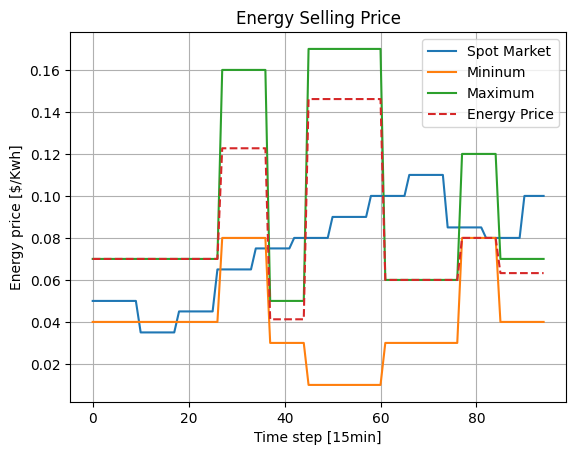

In [10]:
x_data = []
spot_data = []
min_data = []
max_data = []

for p in model_HRP.P:
    for t in range(model_HRP.Q_begin[p], model_HRP.Q_end[p]):    
        x_data.append(pyo.value(x_k[p]))
        spot_data.append(pyo.value(model_HRP.PI[t]))
        min_data.append(pyo.value(model_HRP.X_low[p]))
        max_data.append(pyo.value(model_HRP.X_up[p]))

df = pd.DataFrame({'x': x_data, 'spot': spot_data, 'min': min_data, 'max': max_data})

# Plot the data
plt.plot(df.index, df['spot'], label='Spot Market')
plt.plot(df.index, df['min'], label='Mininum')
plt.plot(df.index, df['max'], label='Maximum')
plt.plot(df.index, df['x'], label='Energy Price', linestyle='--')
plt.xlabel('Time step [15min]')
plt.ylabel('Energy price [$/Kwh]')
plt.title('Energy Selling Price')
plt.grid(True)
plt.legend()
plt.show()

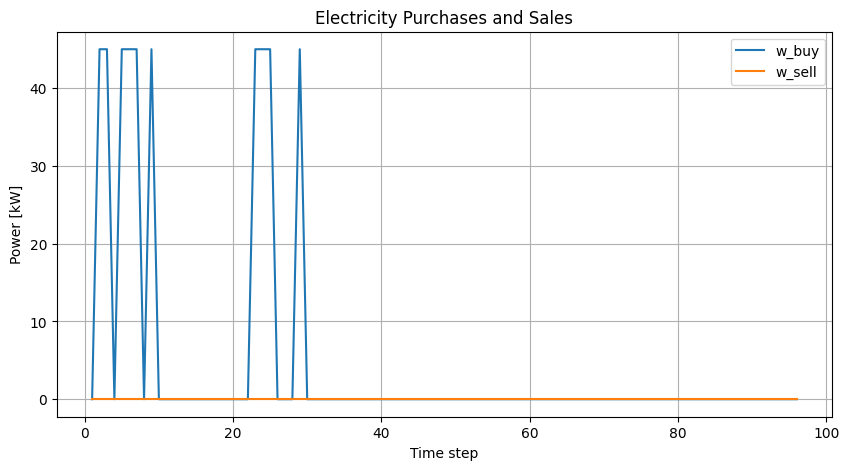

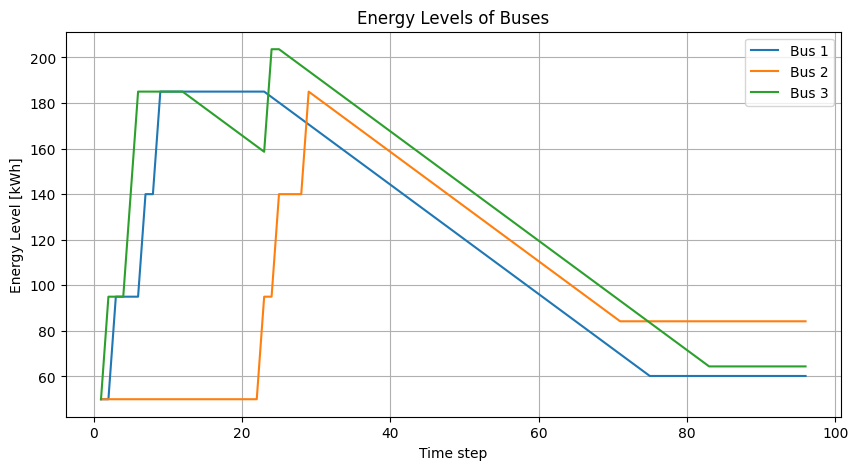

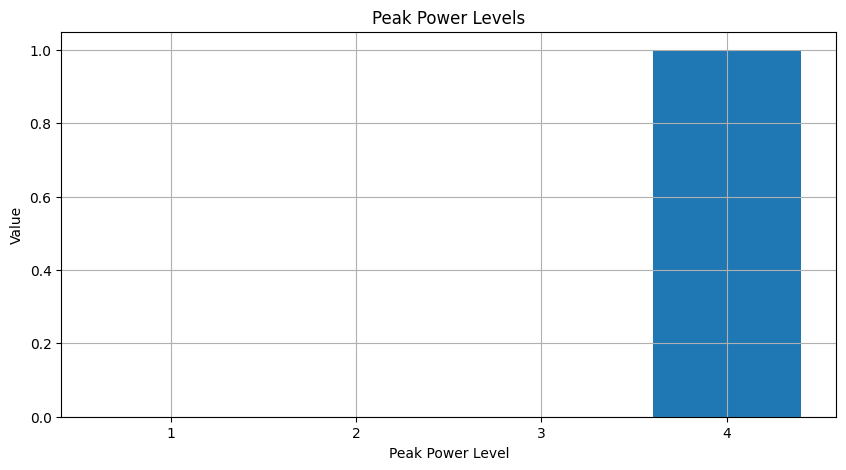

In [12]:
model = model_LL
# Extract variable values from the results
w_buy_values = [model.w_buy[t].value for t in model.T]
w_sell_values = [model.w_sell[t].value for t in model.T]
e_values = np.array([[model.e[k, t].value for t in model.T] for k in model.K])
u_values = [model.u[l].value for l in model.L]
x_values = np.array([[[model.x[k, n, t].value for t in model.T]
                    for n in model.N] for k in model.K])
y_values = np.array([[[model.y[k, n, t].value for t in model.T]
                    for n in model.N] for k in model.K])
c_values = np.array([[model.c[k, t].value for t in model.T] for k in model.K])
d_values = np.array([[model.d[k, t].value for t in model.T] for k in model.K])
b_values = np.array([[[model.b[k, i, t].value for t in model.T]
                    for i in model.I] for k in model.K])

# Plot w_buy and w_sell
plt.figure(figsize=(10, 5))
plt.plot(model.T, w_buy_values, label='w_buy')
plt.plot(model.T, w_sell_values, label='w_sell')
plt.xlabel('Time step')
plt.ylabel('Power [kW]')
plt.title('Electricity Purchases and Sales')
plt.legend()
plt.grid(True)
plt.show()

# Plot energy levels for each bus
plt.figure(figsize=(10, 5))
for k in model.K:
    plt.plot(model.T, e_values[k-1], label=f'Bus {k}')
plt.xlabel('Time step')
plt.ylabel('Energy Level [kWh]')
plt.title('Energy Levels of Buses')
plt.legend()
plt.grid(True)
plt.show()

# Plot peak power level u
plt.figure(figsize=(10, 5))
plt.bar(model.L, u_values)
plt.xlabel('Peak Power Level')
plt.ylabel('Value')
plt.title('Peak Power Levels')
plt.xticks(model.L)
plt.grid(True)
plt.show()